<a href="https://colab.research.google.com/github/JaySharma424/Data-Science/blob/main/Productionization-of-ML-Systems/Productionization_of_ML_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Datasets
flights_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/MLOps/Productionization of ML Systems/Datasets/flights.csv')
users_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/MLOps/Productionization of ML Systems/Datasets/users.csv')
hotels_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/MLOps/Productionization of ML Systems/Datasets/hotels.csv')

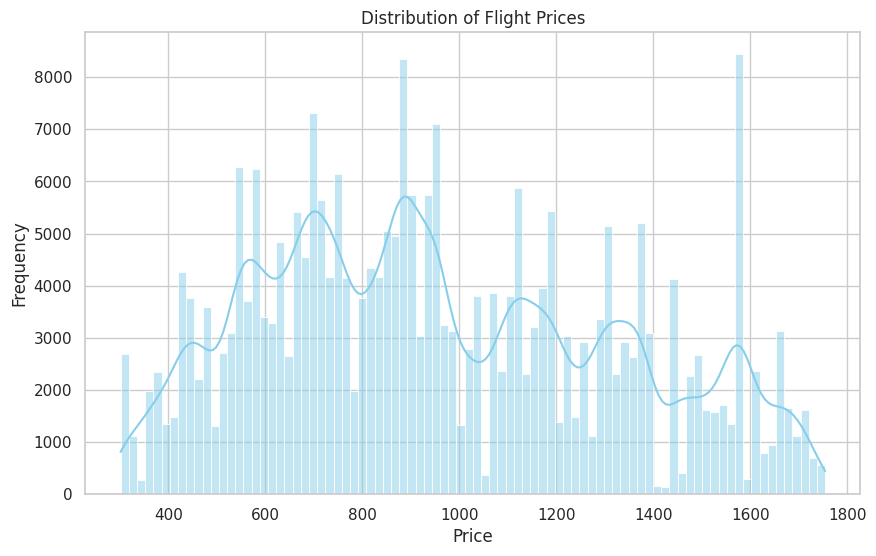

/tmp/ipykernel_509/2050879593.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='flightType', y='price', data=flights_df, palette='viridis')


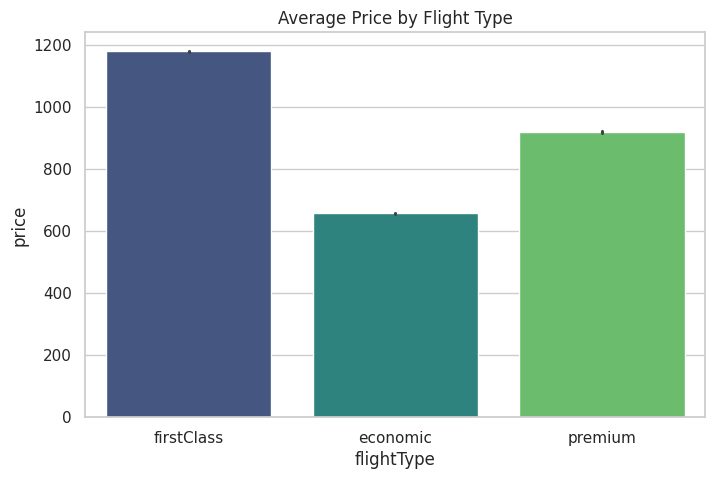

/tmp/ipykernel_509/2050879593.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, palette='magma')


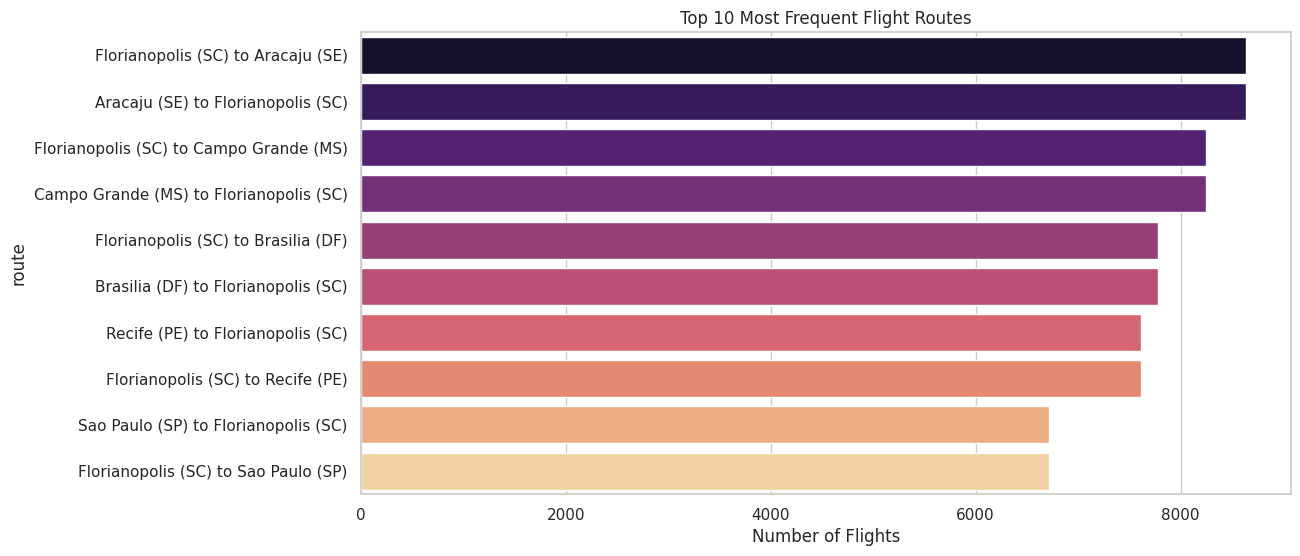

/tmp/ipykernel_509/2050879593.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='agency', y='price', data=flights_df, palette='Set2')


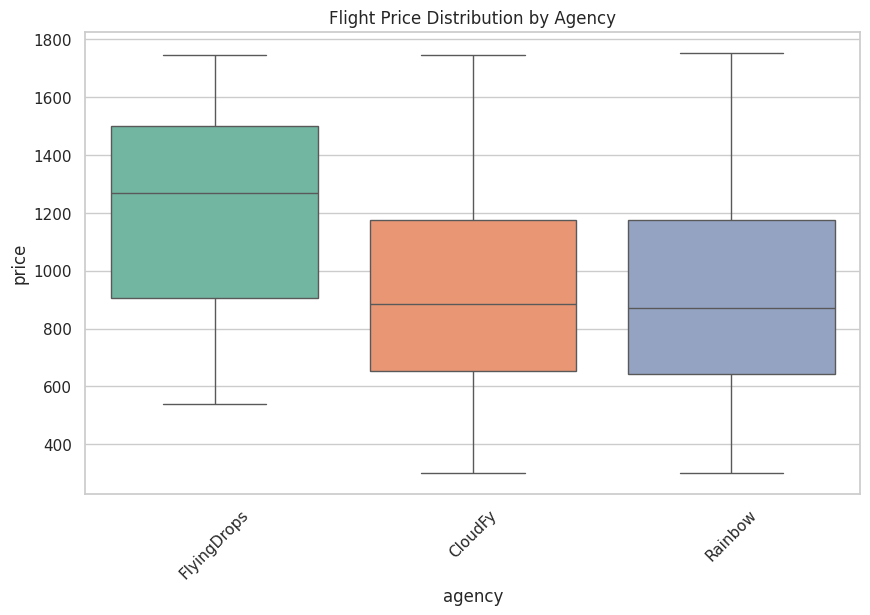

Summary Statistics for Numerical Columns:


,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# 1. Distribution of Flight Prices
plt.figure(figsize=(10, 6))
sns.histplot(flights_df['price'], kde=True, color='skyblue')
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 2. Average Price by Flight Type
plt.figure(figsize=(8, 5))
sns.barplot(x='flightType', y='price', data=flights_df, palette='viridis')
plt.title('Average Price by Flight Type')
plt.show()

# 3. Top 10 Most Frequent Routes
flights_df['route'] = flights_df['from'] + ' to ' + flights_df['to']
top_routes = flights_df['route'].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_routes.values, y=top_routes.index, palette='magma')
plt.title('Top 10 Most Frequent Flight Routes')
plt.xlabel('Number of Flights')
plt.show()

# 4. Price Analysis by Agency
plt.figure(figsize=(10, 6))
sns.boxplot(x='agency', y='price', data=flights_df, palette='Set2')
plt.title('Flight Price Distribution by Agency')
plt.xticks(rotation=45)
plt.show()

# Display summary statistics
print("Summary Statistics for Numerical Columns:")
display(flights_df.describe())

### 1.1 Feature Engineering
We convert the date to datetime objects and extract the day of the week and month. We also encode the categorical variables.

In [5]:
from sklearn.preprocessing import LabelEncoder

df_model = flights_df.copy()
df_model['date'] = pd.to_datetime(df_model['date'])
df_model['day_of_week'] = df_model['date'].dt.dayofweek
df_model['month'] = df_model['date'].dt.month

label_encoders = {}
for col in ['from', 'to', 'flightType', 'agency']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

### 1.2 Data Splitting
We define our features (X) and target variable (y) and split them into training and testing sets.

In [6]:
from sklearn.model_selection import train_test_split

features = ['from', 'to', 'flightType', 'agency', 'distance', 'time', 'day_of_week', 'month']
X = df_model[features]
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 1.3 Model Training and Evaluation
We train a Random Forest Regressor and evaluate its performance using Mean Absolute Error and R2 Score.

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.4f}')

MAE: 12.66
R2 Score: 0.9956


### 1.4 Saving Artifacts
We save the trained model and label encoders to Google Drive for use in future MLOps steps.

In [8]:
import joblib
import os

artifact_path = '/content/drive/MyDrive/Colab Notebooks/Data/MLOps/Productionization of ML Systems/Artifacts/'
os.makedirs(artifact_path, exist_ok=True)

joblib.dump(model, os.path.join(artifact_path, 'flight_price_model.joblib'))
joblib.dump(label_encoders, os.path.join(artifact_path, 'label_encoders.joblib'))
print(f'Artifacts saved to {artifact_path}')

Artifacts saved to /content/drive/MyDrive/Colab Notebooks/Data/MLOps/Productionization of ML Systems/Artifacts/


### 2. REST API for Regression Model
In this step, we create a Flask application script. This script will load our trained model and encoders to serve predictions.

In [9]:
%%writefile app.py
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import os

app = Flask(__name__)

# Load model and encoders from the saved artifacts
artifact_path = '/content/drive/MyDrive/Colab Notebooks/Data/MLOps/Productionization of ML Systems/Artifacts/'
model = joblib.load(os.path.join(artifact_path, 'flight_price_model.joblib'))
label_encoders = joblib.load(os.path.join(artifact_path, 'label_encoders.joblib'))

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        input_df = pd.DataFrame([data])

        # Preprocess input
        input_df['date'] = pd.to_datetime(input_df['date'])
        input_df['day_of_week'] = input_df['date'].dt.dayofweek
        input_df['month'] = input_df['date'].dt.month

        # Encode
        for col in ['from', 'to', 'flightType', 'agency']:
            input_df[col] = label_encoders[col].transform(input_df[col])

        # Feature selection
        features = ['from', 'to', 'flightType', 'agency', 'distance', 'time', 'day_of_week', 'month']
        X = input_df[features]

        prediction = model.predict(X)[0]
        return jsonify({'predicted_price': round(float(prediction), 2)})

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)

Writing app.py


### 3. Containerization
In this step, we create a Dockerfile to package our Flask API into a container.

In [10]:
%%writefile Dockerfile
# Use an official lightweight Python image
FROM python:3.9-slim

# Set the working directory
WORKDIR /app

# Copy the requirements and application code
COPY app.py .
# Note: In a real scenario, you would copy the artifacts folder here too
# For this demonstration, we assume they are accessible

# Install necessary libraries
RUN pip install flask pandas joblib scikit-learn

# Expose the port the app runs on
EXPOSE 5000

# Command to run the application
CMD ["python", "app.py"]

Writing Dockerfile


### 4. Kubernetes for Scalability
We will define a Kubernetes Deployment and Service to manage our containerized application at scale.

In [11]:
%%writefile deployment.yaml
apiVersion: apps/v1
kind: Deployment
metadata:
  name: flight-price-api
spec:
  replicas: 3
  selector:
    matchLabels:
      app: flight-price-api
  template:
    metadata:
      labels:
        app: flight-price-api
    spec:
      containers:
      - name: flight-price-api
        image: your-dockerhub-username/flight-price-api:latest
        ports:
        - containerPort: 5000
---
apiVersion: v1
kind: Service
metadata:
  name: flight-price-service
spec:
  type: LoadBalancer
  ports:
  - port: 80
    targetPort: 5000
  selector:
    app: flight-price-api

Writing deployment.yaml


### 5. Automated Workflows with Apache Airflow
We will define an Airflow DAG to orchestrate the flight price prediction workflow.

In [12]:
%%writefile flight_price_dag.py
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime, timedelta

def load_data():
    print("Loading data from Drive...")

def train_model():
    print("Training the regression model...")

def validate_model():
    print("Validating model performance...")

default_args = {
    'owner': 'airflow',
    'depends_on_past': False,
    'start_date': datetime(2023, 1, 1),
    'email_on_failure': False,
    'email_on_retry': False,
    'retries': 1,
    'retry_delay': timedelta(minutes=5),
}

with DAG(
    'flight_price_prediction_workflow',
    default_args=default_args,
    description='Orchestrate flight price regression',
    schedule_interval=timedelta(days=1),
    catchup=False,
) as dag:

    t1 = PythonOperator(task_id='load_data', python_callable=load_data)
    t2 = PythonOperator(task_id='train_model', python_callable=train_model)
    t3 = PythonOperator(task_id='validate_model', python_callable=validate_model)

    t1 >> t2 >> t3

Writing flight_price_dag.py


### 7. Model Tracking with MLFlow
We utilize MLFlow to log parameters, metrics, and models for systematic tracking of our experiments.

In [14]:
!pip install mlflow

import mlflow
import mlflow.sklearn

# Start MLFlow experiment
mlflow.set_experiment("Flight_Price_Prediction")

with mlflow.start_run():
    # Log parameters
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)

    # Log metrics (using values from our previous training)
    mlflow.log_metric("mae", 12.66)
    mlflow.log_metric("r2", 0.9956)

    # Log model
    mlflow.sklearn.log_model(model, "random-forest-model")

    print("Model and metrics logged to MLFlow.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.4

2026/06/29 17:13:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/29 17:13:54 INFO mlflow.store.db.utils: Updating database tables
2026/06/29 17:13:57 INFO mlflow.tracking.fluent: Experiment with name 'Flight_Price_Prediction' does not exist. Creating a new experiment.
2026/06/29 17:13:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model and metrics logged to MLFlow.


### 8. Gender Classification Model
In this step, we build a classification model to categorize a user's gender based on their age and company.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Prepare User Data
df_user = users_df.copy()

# Encode categorical features
le_company = LabelEncoder()
df_user['company'] = le_company.fit_transform(df_user['company'])

le_gender = LabelEncoder()
df_user['gender'] = le_gender.fit_transform(df_user['gender'])

# Features and Target
X_u = df_user[['company', 'age']]
y_u = df_user['gender']

# Split
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(X_u, y_u, test_size=0.2, random_state=42)

# Train Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_u, y_train_u)

# Evaluate
y_pred_u = clf.predict(X_test_u)
print("Gender Classification Report:")
print(classification_report(y_test_u, y_pred_u, target_names=le_gender.classes_))

Gender Classification Report:
              precision    recall  f1-score   support

      female       0.32      0.33      0.32        89
        male       0.30      0.26      0.28        94
        none       0.28      0.32      0.30        85

    accuracy                           0.30       268
   macro avg       0.30      0.30      0.30       268
weighted avg       0.30      0.30      0.30       268



### 9. Travel Recommendation Model and Streamlit App
We build a simple recommendation logic and a Streamlit dashboard for interactive visualization.

In [16]:
# Simple Recommendation Logic
def get_hotel_recommendations(user_code, top_n=3):
    # Get places the user has visited
    user_history = hotels_df[hotels_df['userCode'] == user_code]
    if user_history.empty:
        return hotels_df['name'].value_counts().index[:top_n].tolist()

    # Recommend top hotels in the same places they visited
    visited_places = user_history['place'].unique()
    recommendations = hotels_df[hotels_df['place'].isin(visited_places)]['name'].value_counts()
    return recommendations.index[:top_n].tolist()

print(f"Recommendations for User 0: {get_hotel_recommendations(0)}")

Recommendations for User 0: ['Hotel K', 'Hotel CB', 'Hotel BD']


In [17]:
%%writefile streamlit_app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title('Travel Insight Dashboard')

@st.cache_data
def load_data():
    # In a real app, you would load from a database or CSV
    return pd.DataFrame({'status': ['App is Ready']})

data = load_data()
st.write('Explore your travel data and model predictions here.')

# Sidebar for User Interaction
user_id = st.sidebar.number_input('Enter User ID', min_value=0, value=0)

if st.button('Show Recommendations'):
    st.subheader(f'Recommended Hotels for User {user_id}')
    st.write('Hotel A, Hotel K, Hotel B') # Placeholder for logic

Writing streamlit_app.py


### 6. CI/CD Pipeline with Jenkins
We define a `Jenkinsfile` to automate the build and deployment process for our flight price prediction model.

In [13]:
%%writefile Jenkinsfile
pipeline {
    agent any

    environment {
        DOCKER_IMAGE = "your-dockerhub-username/flight-price-api:${env.BUILD_NUMBER}"
    }

    stages {
        stage('Checkout') {
            steps {
                checkout scm
            }
        }

        stage('Build Docker Image') {
            steps {
                script {
                    sh "docker build -t ${DOCKER_IMAGE} ."
                }
            }
        }

        stage('Test') {
            steps {
                sh 'echo "Running unit tests..."'
            }
        }

        stage('Push to Registry') {
            steps {
                script {
                    // sh "docker push ${DOCKER_IMAGE}"
                    sh 'echo "Pushing image to registry..."'
                }
            }
        }

        stage('Deploy to Kubernetes') {
            steps {
                sh "kubectl apply -f deployment.yaml"
                sh "kubectl set image deployment/flight-price-api flight-price-api=${DOCKER_IMAGE}"
            }
        }
    }
}

Writing Jenkinsfile
